# FoodHub Data Analysis


### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

In [5]:
# cleaned notebook


In [6]:
print("THIS IS A TEST CHANGE")

THIS IS A TEST CHANGE


### Import the required libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns


In [3]:
food_hub = pd.read_excel('foodhub_order.xlsx')


### Import your data

In [ ]:
import pandas as pd

#import data
#food_hub.sample
%pip install openpyxl

food_hub = pd.read_excel('foodhub_order.xlsx')



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24
...,...,...,...,...,...,...,...,...,...
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31


### Do sanity checks on the data

In [4]:
food_hub.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [5]:
#checking for the stats
food_hub.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


In [6]:
#check for inforation
food_hub.info()


<class 'pandas.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   str    
 3   cuisine_type           1898 non-null   str    
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   str    
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(1), str(3)
memory usage: 133.6+ KB


In [7]:
#check for duplicates
food_hub.duplicated().sum()

np.int64(0)

***From the data, there are no duplicates***

In [8]:
#check for the columns and rows
food_hub.shape

(1898, 9)

From the data, we have 1898 rows and 9 columns

In [9]:
#check for columns
food_hub.columns.to_list()

['order_id',
 'customer_id',
 'restaurant_name',
 'cuisine_type',
 'cost_of_the_order',
 'day_of_the_week',
 'rating',
 'food_preparation_time',
 'delivery_time']

In [10]:
#check for missing values
food_hub.isnull()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
1893,False,False,False,False,False,False,False,False,False
1894,False,False,False,False,False,False,False,False,False
1895,False,False,False,False,False,False,False,False,False
1896,False,False,False,False,False,False,False,False,False


In [11]:
food_hub.isnull().sum()

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

In [12]:
food_hub.isnull().sum() / len(food_hub) * 100

order_id                 0.0
customer_id              0.0
restaurant_name          0.0
cuisine_type             0.0
cost_of_the_order        0.0
day_of_the_week          0.0
rating                   0.0
food_preparation_time    0.0
delivery_time            0.0
dtype: float64

## Questions for guidance.
The questions or tasks below are meant to giuide you to extract insight for the business. You are encourage to ask more questions.


### **Question 1:** How many orders are not rated?


In [13]:
# Write the code here.
#Feel free to add more cells.

not_rated = food_hub['rating'].value_counts()[['Not given']]
not_rated



rating
Not given    736
Name: count, dtype: int64

***Answer: from the output 736 orders are not rated***

In [14]:
(food_hub['rating'] == 'Not given').sum()

np.int64(736)

In [15]:
food_hub.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


## Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 2:** Explore all the variables and provide observations on their distributions. (Choose appropriate plots as you wish)

In [16]:
# Write the code here.
#Feel free to add more cells.
food_hub.head(5)

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


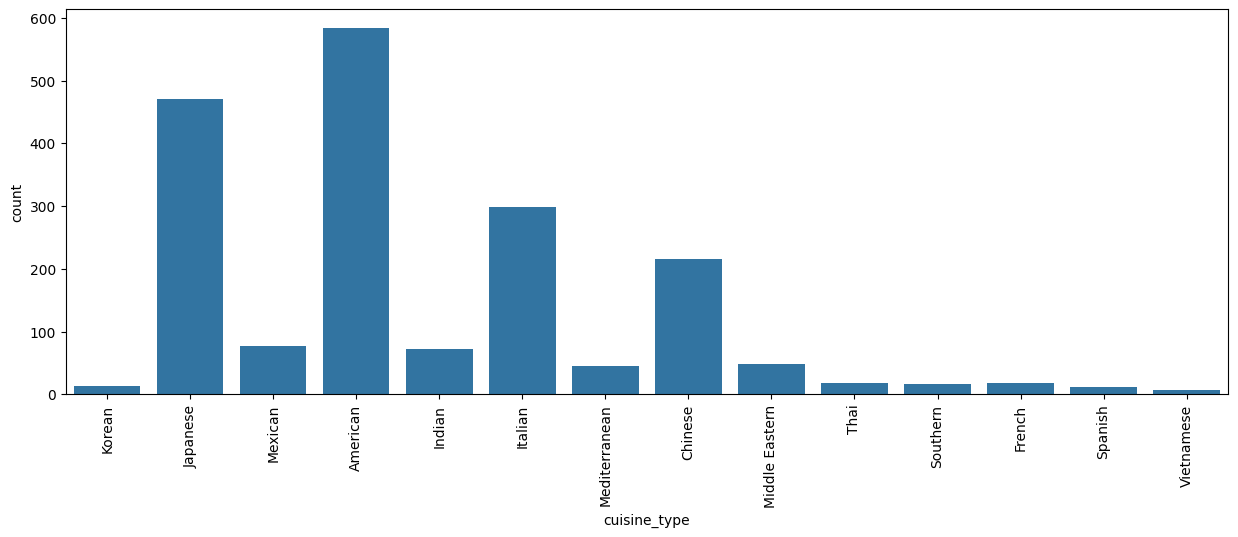

In [17]:
# 1. Distribution of Cuisine Type (Count Plot)
plt.figure(figsize=(15,5))
sns.countplot(data=food_hub, x='cuisine_type')
plt.xticks(rotation=90)
plt.show()


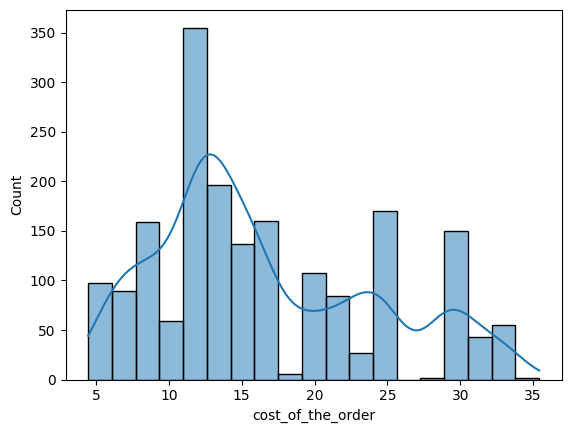

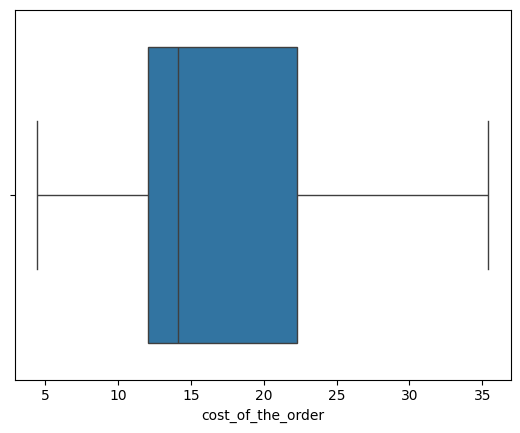

In [18]:
# 2. Distribution of Order Cost (Histogram and Boxplot)
sns.histplot(data=food_hub, x='cost_of_the_order', kde=True)
plt.show()
sns.boxplot(data=food_hub, x='cost_of_the_order')
plt.show()


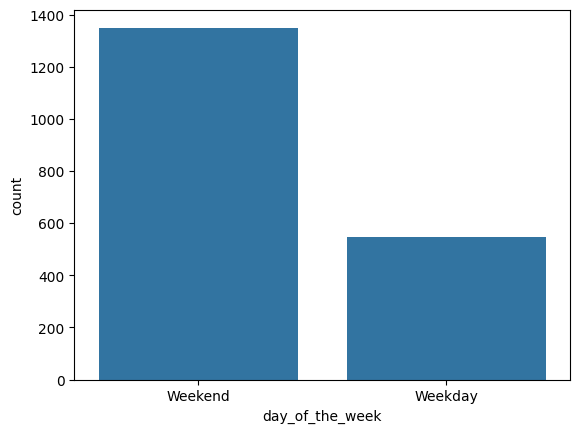

In [19]:
# 3. Distribution of Day of the Week (Count Plot)
sns.countplot(data=food_hub, x='day_of_the_week')
plt.show()

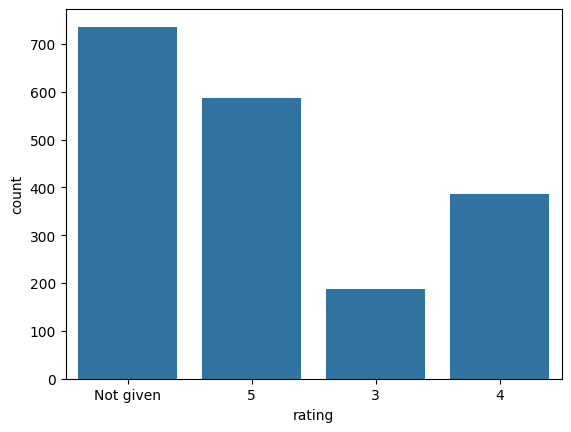

In [20]:
# 4. Distribution of Ratings (Count Plot)
sns.countplot(data=food_hub, x='rating')
plt.show()

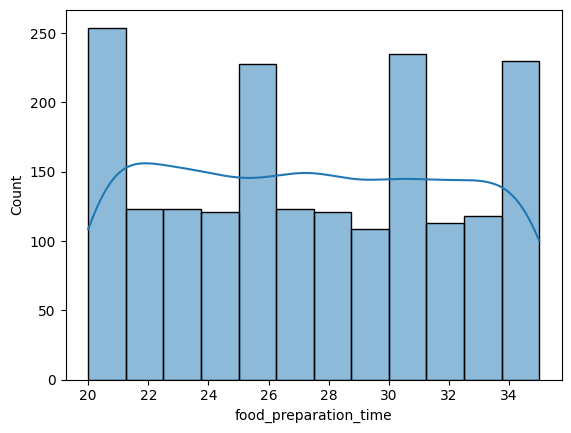

In [21]:
# 5. Distribution of Food Preparation Time (Histogram)
sns.histplot(data=food_hub, x='food_preparation_time', kde=True)
plt.show()

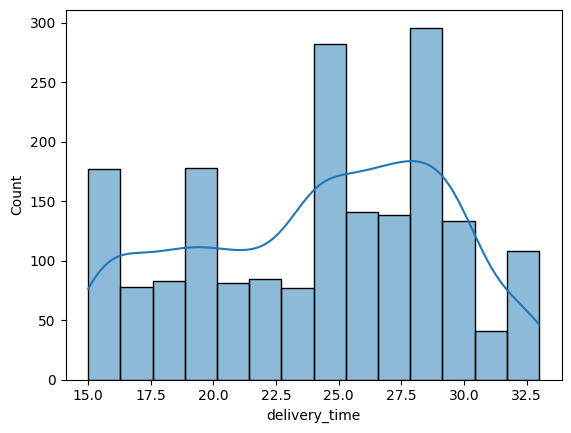

In [22]:
# 6. Distribution of Delivery Time (Histogram)
sns.histplot(data=food_hub, x='delivery_time', kde=True)
plt.show()


Insights for the Business

Targeting: Since the majority of orders occur on the weekend, the business could focus marketing efforts or driver availability during those times
.

Customer Engagement: The high number of "Not given" ratings suggests a need for a more engaging feedback system to capture customer satisfaction data
.

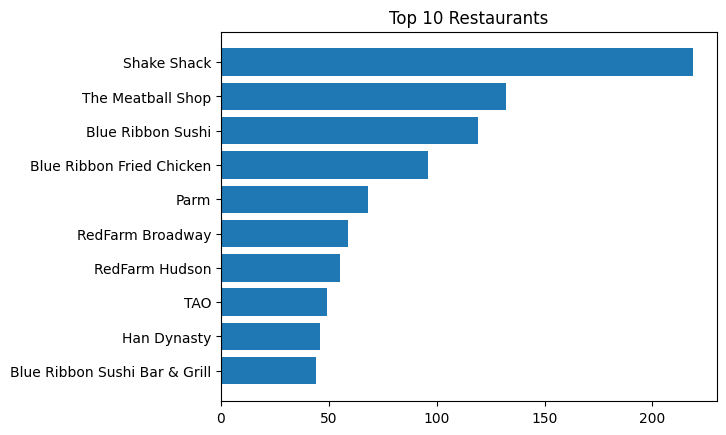

In [23]:
restaurant_counts = food_hub['restaurant_name'].value_counts()
top_10 = restaurant_counts.head(10)
top_10 = top_10.sort_values(ascending=True)
plt.barh(top_10.index, top_10.values)
plt.title('Top 10 Restaurants')
plt.show()

<Axes: xlabel='cost_of_the_order', ylabel='Count'>

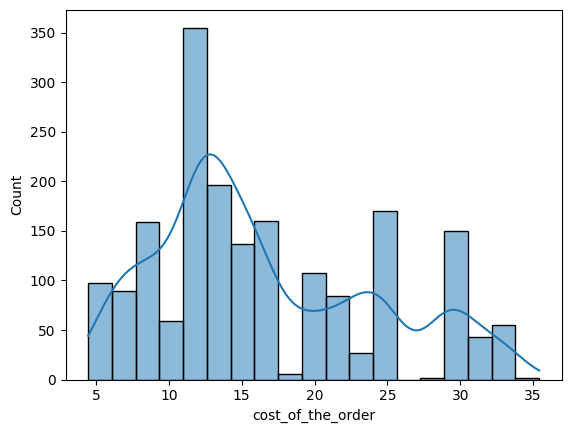

In [24]:
#histogram
sns.histplot(data= food_hub, x= 'cost_of_the_order', kde = True)

### **Question 3**: Which are the top 5 restaurants in terms of the number of orders received?

<Axes: >

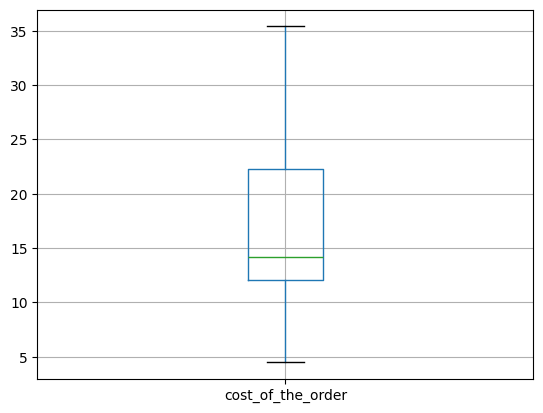

In [25]:
food_hub.boxplot(column='cost_of_the_order')


### **Question 4**: Which is the most popular cuisine on weekends?

In [26]:
# Write the code here
# Feel free to add more cells

# Filter the data for weekend orders only
weekend_food_hub = food_hub[food_hub['day_of_the_week'] == 'Weekend']
weekend_food_hub


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
6,1477894,157711,The Meatball Shop,Italian,6.07,Weekend,Not given,28,21
11,1478437,221206,Empanada Mama (closed),Mexican,8.10,Weekend,5,23,22
...,...,...,...,...,...,...,...,...,...
1891,1476981,138586,Shake Shack,American,5.82,Weekend,Not given,22,28
1892,1477473,97838,Han Dynasty,Chinese,29.15,Weekend,Not given,29,21
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19


In [27]:
# Identify the most frequent cuisine type on weekends
most_popular_weekend = weekend_food_hub['cuisine_type'].value_counts().idxmax()
count = weekend_food_hub['cuisine_type'].value_counts().max()

print(f"The most popular cuisine on weekends is {most_popular_weekend} with {count} orders.")

The most popular cuisine on weekends is American with 415 orders.


In [28]:
most_popular_weekend

'American'

In [ ]:
count

### **Question 5**: What percentage of the orders cost more than 20 dollars?

In [29]:
# Write the code here
# Feel free to add more cells

# Count unique order IDs to find the true total number of orders
unique_order_count = food_hub['order_id'].nunique()
unique_order_count


1898

In [30]:
# 2. Filter for orders > 20 and count those unique order IDs
expensive_orders = food_hub[food_hub['cost_of_the_order'] > 20]['order_id'].nunique()
expensive_orders


555

In [ ]:
# 3. Calculate the percentage
total_orders = food_hub.shape[0]
percentage = (expensive_orders / total_orders) * 100
percentage

In [ ]:
# Display the result
print(f"Percentage of orders costing more than $20: {percentage:.2f}%")

Business Insight:

Since about 29% of orders are in this higher price range, the company could offer special fees or rewards for orders above $20 to encourage customers to spend more.

### **Question 6**: What is the mean order delivery time?

In [31]:
# Write the code here
# Feel free to add more cells

# Calculate the mean of the delivery_time column
mean_delivery_time = food_hub['delivery_time'].mean()

# Display the result
print(f"The mean delivery time is: {mean_delivery_time:.2f} minutes")

The mean delivery time is: 24.16 minutes


Business Insight:
    
Knowing the average delivery time is 24 minutes is critical for managing customer expectations

### **Question 7:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [32]:
# Write the code here
# Feel free to add more cells

# Get the top 3 most frequent customers and their order counts
top_3_customers = food_hub['customer_id'].value_counts().head(3)

# Display the results
print("Top 3 Most Frequent Customers:")
print(top_3_customers)

Top 3 Most Frequent Customers:
customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64


## Bivariate/Multivariate Analysis

### **Question 8**: Perform a bivariate/multivariate analysis to explore relationships between the important variables in the dataset.


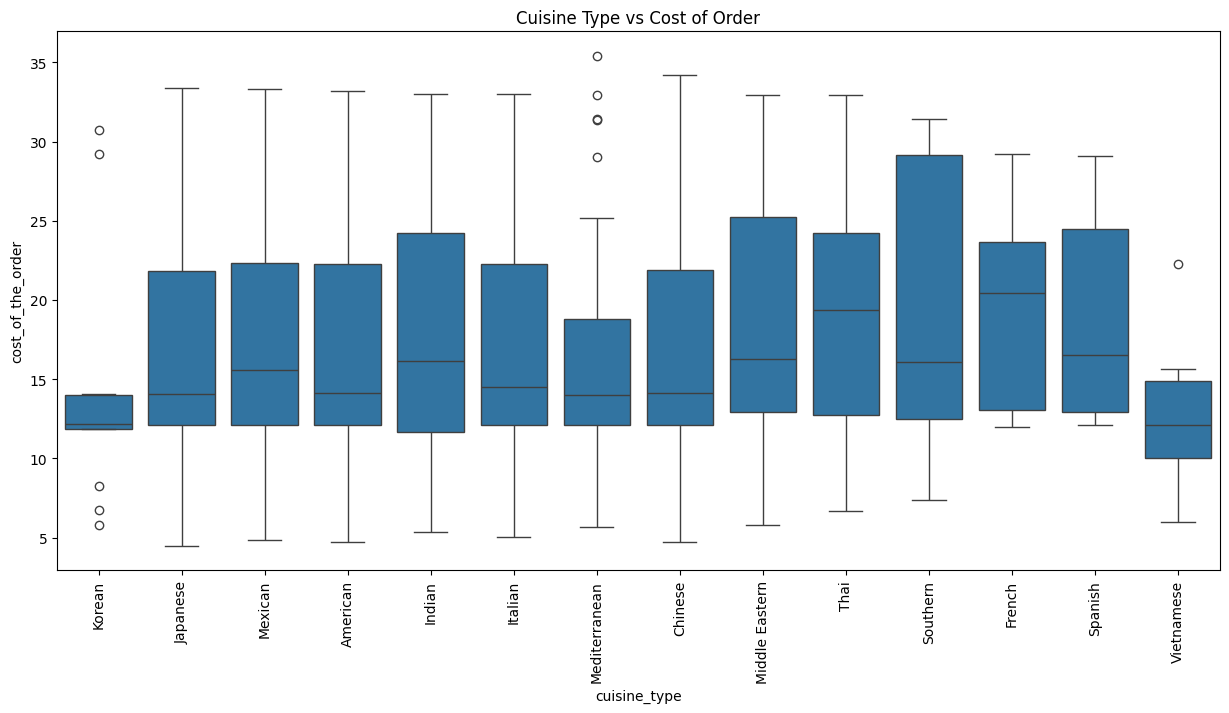

In [33]:
# Write the code here
# Feel free to add more cells

# 1. Cuisine vs Cost (Bivariate)
plt.figure(figsize=(15,7))
sns.boxplot(data=food_hub, x='cuisine_type', y='cost_of_the_order')
plt.xticks(rotation=90)
plt.title('Cuisine Type vs Cost of Order')
plt.show()

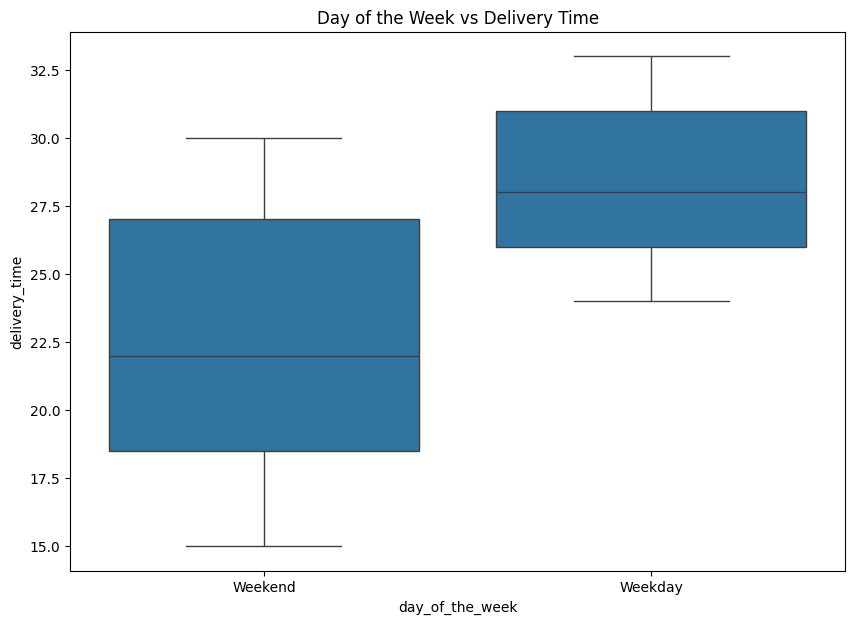

In [34]:
# 2. Day of the Week vs Delivery Time (Bivariate)
plt.figure(figsize=(10,7))
sns.boxplot(data=food_hub, x='day_of_the_week', y='delivery_time')
plt.title('Day of the Week vs Delivery Time')
plt.show()

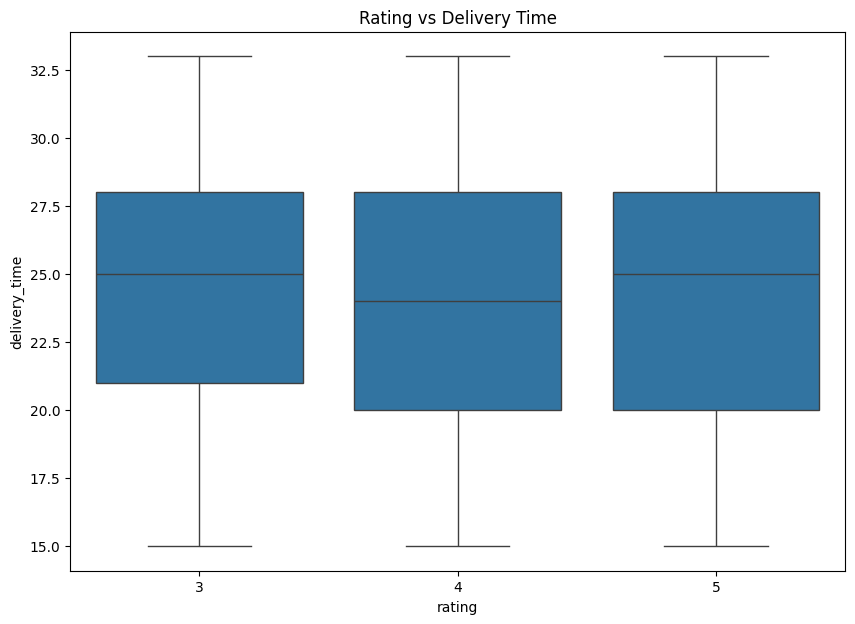

In [35]:
# 3. Rating vs Delivery Time (Bivariate)
# Note: Filter out 'Not given' to see the relationship clearly
rated_df = food_hub[food_hub['rating'] != 'Not given'].copy()
rated_df['rating'] = rated_df['rating'].astype(int)
plt.figure(figsize=(10,7))
sns.boxplot(data=rated_df, x='rating', y='delivery_time')
plt.title('Rating vs Delivery Time')
plt.show()

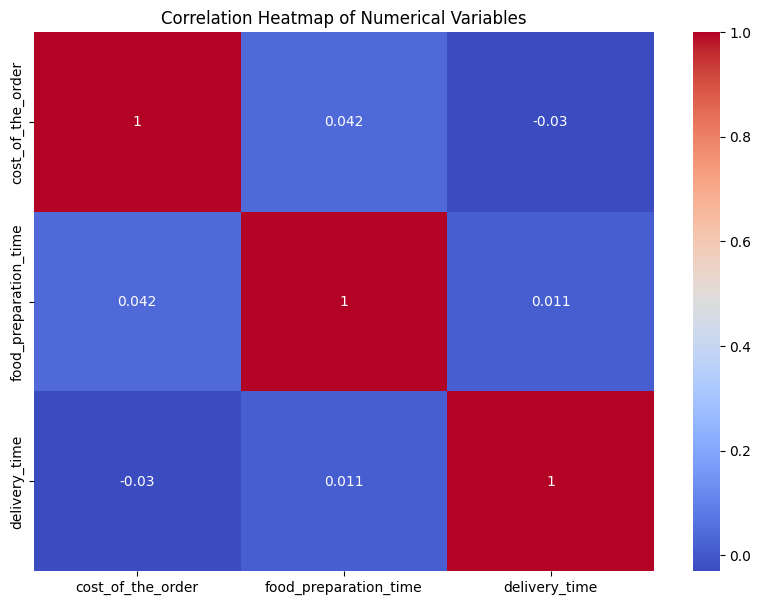

In [36]:
# 4. Correlation Heatmap (Multivariate)
# Examine the relationship between all numerical variables
plt.figure(figsize=(10,7))
sns.heatmap(food_hub[['cost_of_the_order', 'food_preparation_time', 'delivery_time']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

Business Insights:
    
Because delivery times are significantly higher on weekdays, the business should investigate if this is due to traffic or a shortage of delivery personnel during those hours.
    
Also, since cuisines like French and Thai command higher prices, these could be featured in premium marketing campaigns.
    
Again, since delivery time doesn't always correlate with ratings, the company should focus on food preparation quality and accuracy, as these likely play a larger role in customer satisfaction.

### **Question 9:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer.

In [37]:
# Write the code here
# Feel free to add more cells

# 1. Filter out orders where the rating was 'Not given'
food_hub_rated = food_hub[food_hub['rating'] != 'Not given'].copy()

# 2. Convert the rating column to integers to allow math calculations
food_hub_rated['rating'] = food_hub_rated['rating'].astype(int)

# 3. Group by restaurant and calculate the count of ratings and the average (mean)
promo_food_hub = food_hub_rated.groupby('restaurant_name')['rating'].agg(['count', 'mean'])

# 4. Filter for restaurants with more than 50 ratings and an average > 4
eligible_restaurants = promo_food_hub[(promo_food_hub['count'] > 50) & (promo_food_hub['mean'] > 4)]

# Display the results
print(eligible_restaurants)

                           count      mean
restaurant_name                           
Blue Ribbon Fried Chicken     64  4.328125
Blue Ribbon Sushi             73  4.219178
Shake Shack                  133  4.278195
The Meatball Shop             84  4.511905



Business Insight:
    
By choosing these restaurants, the company is rewarding partners that are both busy and dependable. These restaurants handle many orders and still keep good ratings (above 4), showing they deliver quality even at high volume.

### **Question 10:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders.

In [38]:
# Write the code here
# Feel free to add more cells

# Define a function to calculate revenue per order based on the cost
def calculate_revenue(cost):
    if cost > 20:
        return cost * 0.25
    elif cost > 5:
        return cost * 0.15
    else:
        return 0

# Apply the function to create a new revenue column
food_hub['revenue'] = food_hub['cost_of_the_order'].apply(calculate_revenue)

# Calculate the sum of the revenue column
total_net_revenue = food_hub['revenue'].sum()

# Display the result
print(f"The net revenue generated by the company across all orders is: ${total_net_revenue:.2f}")

The net revenue generated by the company across all orders is: $6166.30


### **Question 11:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.)

In [39]:
# Write the code here
# Feel free to add more cells

# 1. Create a new column for total delivery time (Prep + Delivery)
food_hub['total_time'] = food_hub['food_preparation_time'] + food_hub['delivery_time']

# 2. Count the number of orders where total_time is greater than 60
orders_over_60 = len(food_hub[food_hub['total_time'] > 60])

# 3. Calculate the percentage relative to the total number of orders
total_orders = len(food_hub)
percentage = (orders_over_60 / total_orders) * 100

# Display the result
print(f"Percentage of orders taking more than 60 minutes: {percentage:.2f}%")

Percentage of orders taking more than 60 minutes: 10.54%


### **Question 12:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends?

In [ ]:
# Group by weekday/weekend and calculate the mean delivery time
mean_delivery_by_period = food_hub.groupby('day_of_the_week')['delivery_time'].mean()

# Display the results
print("Mean Delivery Time by Weekday/Weekend:")
print(mean_delivery_by_period)

Mean Delivery Time by Day of the Week:
day_of_the_week
Weekday    28.340037
Weekend    22.470022
Name: delivery_time, dtype: float64


## Conclusion and Recommendations

### **Question 13:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.)

### Conclusions:
*  Business Insight
  
From looking at the delivery data, here are the main takeaways and suggestions to improve the business.

* Key Findings

Popular Cuisines: American, Japanese, and Italian foods get the most orders. Restaurants like Shake Shack, The Meatball Shop, and Blue Ribbon Sushi are customer favorites.

Weekday vs Weekend Performance: Weekends have more orders but faster deliveries (about 22 minutes) compared to weekdays (about 28 minutes). This suggests there may be delays or inefficiencies during the work week.

Lack of Customer Feedback: Many orders don’t have ratings, even from top restaurants. This makes it hard to know how satisfied customers really are.

High-Value Orders: About 29% of orders are over $20, where the company earns the most commission. These orders often come from cuisines like French, Thai, and Indian.

Long Wait Times: Around 10% of customers wait more than an hour for their food, which could lead to unhappy customers and fewer repeat orders.

### Recommendations:

* Improve Customer Feedback:
Many customers don’t leave ratings. To fix this, the company can offer small rewards like credits or loyalty points when customers rate their orders. This will help the business understand customer satisfaction better.

* Fix Weekday Delivery Delays:
Deliveries are slower on weekdays, even though there are fewer orders. The company should look into this and improve efficiency. For example, they can add more drivers or offer incentives during weekdays to speed things up.

* Target Marketing Better:
Weekend Promotions: Since American and Japanese food are popular on weekends, the company can run special weekend deals for these cuisines.

* Encourage Bigger Orders: Offer deals like “Spend $25, Get Free Delivery” to get customers to order more and increase revenue.

* Work with Slow Restaurants:
Some delays happen because food takes too long to prepare. The company should work with restaurants that have long prep times to help them speed up their process, especially for delivery orders.

* Reward Loyal Customers:
Give discounts or special offers to frequent customers. For example, customers who order often can get rewards or be part of a “Gold Member” program to encourage them to keep ordering.

---